## Local Inference on GPU
Model page: https://huggingface.co/timm/mobilenetv3_small_100.lamb_in1k

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/timm/mobilenetv3_small_100.lamb_in1k)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [10]:
!pip install tensorflow tensorflow-datasets torch torchvision datasets

In [65]:
from datasets import load_dataset, DatasetDict, load_from_disk
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas, numpy, matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import tensorflow as tf
import timm
import os


from PIL import Image
from google.colab import files
from huggingface_hub import notebook_login

import torch
from torchvision import transforms
import torch.nn as nn
import torchvision.models as models
from torchvision.datasets import SUN397
from torch.utils.data import Subset
from torch.utils.data import DataLoader

# **DATA LOADING AND PREPROCESSING**

In [12]:
#LOADING THREE PRETRAINED NEURAL NETWORKS TO FINE-TUNE
model_mob = timm.create_model("hf_hub:timm/mobilenetv3_small_100.lamb_in1k", pretrained=True)
model_eff = timm.create_model("hf_hub:timm/efficientnet_b0.ra_in1k", pretrained=True)
model_res = timm.create_model("hf_hub:timm/resnet18.a1_in1k", pretrained=True)

In [13]:
#LOAD SUN397 DATABASE
dataset = load_dataset("tanganke/sun397")  # downloads from Hugging Face
print(dataset)

#READ LABELS TO PICK SUBSET
feature = dataset["train"].features["label"]
print(feature.names)       # first 50 class names
print(len(feature.names))       # should be 397

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

data/train-00005-of-00018.parquet:   0%|          | 0.00/476M [00:00<?, ?B/s]

...

data/test-00016-of-00018.parquet:   0%|          | 0.00/424M [00:00<?, ?B/s]

data/test-00017-of-00018.parquet:   0%|          | 0.00/366M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/19850 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/19850 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 19850
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 19850
    })
})
['abbey', 'airplane cabin', 'airport terminal', 'alley', 'amphitheater', 'amusement arcade', 'amusement park', 'anechoic chamber', 'apartment building outdoor', 'apse indoor', 'aquarium', 'aqueduct', 'arch', 'archive', 'arrival gate outdoor', 'art gallery', 'art school', 'art studio', 'assembly line', 'athletic field outdoor', 'atrium public', 'attic', 'auditorium', 'auto factory', 'badlands', 'badminton court indoor', 'baggage claim', 'bakery shop', 'balcony exterior', 'balcony interior', 'ball pit', 'ballroom', 'bamboo forest', 'banquet hall', 'bar', 'barn', 'barndoor', 'baseball field', 'basement', 'basilica', 'basketball court outdoor', 'bathroom', 'batters box', 'bayou', 'bazaar indoor', 'bazaar outdoor', 'beach', 'beauty salon', 'bedroom', 'berth', 'biology laboratory', 'bistro indoor', 

In [14]:
#THE TEN CLASSES TO TRAIN ON
classes = [
    "beach",
    "bedroom",
    "kitchen",
    "living room",
    "office",
    "mountain",
    "highway",
    "street",
    "church indoor",
    "forest broadleaf",
]


In [15]:
#FILTERS DATASET TO GRAB SUBSET
dataset = load_dataset("tanganke/sun397")  # downloads once and caches locally

# Inspect label names
id_to_label = dataset["train"].features["label"].int2str
label_to_id = dataset["train"].features["label"].str2int

class_ids = [label_to_id(name) for name in classes]

# Filter to keep only the chosen 10 classes
def selected_classes(example):
    return example["label"] in class_ids

train_ds = dataset["train"].filter(selected_classes)
val_ds   = dataset["validation"].filter(selected_classes) if "validation" in dataset else dataset["test"].filter(selected_classes)

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Filter:   0%|          | 0/19850 [00:00<?, ? examples/s]

Filter:   0%|          | 0/19850 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [39]:
#CACHE SUBSET AND SAVE LOCALLY
subset = DatasetDict({
    "train": train_ds,
    "validation": val_ds,   # or "test" if that’s what you used
})

full_dataset = DatasetDict({
    "data": dataset
})

#subset.save_to_disk("sun_subset_10")
#full_dataset.save_to_disk("sun_dataset")

!zip -r sun_subset_10.zip sun_subset_10
!zip -r sun_dataset.zip sun_dataset
files.download("sun_subset_10.zip")

  adding: sun_subset_10/ (stored 0%)
  adding: sun_subset_10/dataset_dict.json (stored 0%)
  adding: sun_subset_10/validation/ (stored 0%)
  adding: sun_subset_10/validation/data-00000-of-00001.arrow (deflated 3%)
  adding: sun_subset_10/validation/dataset_info.json (deflated 80%)
  adding: sun_subset_10/validation/state.json (deflated 37%)
  adding: sun_subset_10/train/ (stored 0%)
  adding: sun_subset_10/train/data-00000-of-00001.arrow (deflated 2%)
  adding: sun_subset_10/train/dataset_info.json (deflated 80%)
  adding: sun_subset_10/train/state.json (deflated 38%)
  adding: sun_dataset/ (stored 0%)
  adding: sun_dataset/dataset_dict.json (stored 0%)
  adding: sun_dataset/validation/ (stored 0%)
  adding: sun_dataset/validation/data-00000-of-00001.arrow (deflated 3%)
  adding: sun_dataset/validation/dataset_info.json (deflated 80%)
  adding: sun_dataset/validation/state.json (deflated 37%)
  adding: sun_dataset/train/ (stored 0%)
  adding: sun_dataset/train/data-00000-of-00001.arrow

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **MODEL TRAINING**

In [41]:
#LOAD FULL DATASET OR SUBSET FROM COLAB FILES
subset = load_from_disk("/content/sun_subset_10")
train_ds = subset["train"]
val_ds   = subset["validation"]

In [40]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 10

In [20]:
#TRANSFORM TRAINING AND VALIDATION DATA INTO 224X224 TENSORS WITH RGB
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [21]:
#HANDLES IMAGE TENSOR TRANSFORMATIONS AND CLASS MAPPING
class Dataset_Transform(torch.utils.data.Dataset):
    def __init__(self, hf_split, transform, easy_ids, id2label, label2id):
        self.ds = hf_split
        self.transform = transform
        self.easy_ids = set(easy_ids)
        # build compact 0–9 labels
        self.old2new = {old: new for new, old in enumerate(easy_ids)}

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        ex = self.ds[idx]
        img = ex["image"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)
        y_old = ex["label"]
        y = self.old2new[y_old]
        img = self.transform(img)
        return img, y

In [22]:
train_data = Dataset_Transform(train_ds, train_transform, class_ids, id_to_label, label_to_id)
val_data   = Dataset_Transform(val_ds, val_transform, class_ids, id_to_label, label_to_id)


train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#BUILD CLASSIFIERS USING PRETRAINED NETWORKS
def build_resnet18(num_classes=NUM_CLASSES, freeze_backbone=False):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model.to(device)

def build_efficientnet_b0(num_classes=NUM_CLASSES, freeze_backbone=False):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model.to(device)

def build_mobilenet_v3(num_classes=NUM_CLASSES, freeze_backbone=False):
    model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    return model.to(device)

In [63]:
def plot_normalized_confusion_matrix(model, data_loader, class_names, title="Normalized Confusion Matrix"):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(class_names))),
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, values_format=".2f", colorbar=True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return cm

In [62]:
#TRAIN A MODEL
def train_one_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = outputs.max(1)
                val_correct += preds.eq(labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        print(f"Epoch {epoch+1}/{epochs} | loss={train_loss:.4f} | train_acc={train_acc:.3f} | val_acc={val_acc:.3f}")

    return model

In [64]:
#RUN THE TRAINING PROGRAM ON ALL THREE MODELS
resnet18 = build_resnet18()
efficientnet_b0 = build_efficientnet_b0()
mobilenet_v3 = build_mobilenet_v3()

print("Training ResNet‑18")
resnet18 = train_one_model(resnet18, train_loader, val_loader, epochs=10, lr=1e-3)

print("Training EfficientNet‑B0")
efficientnet_b0 = train_one_model(efficientnet_b0, train_loader, val_loader, epochs=10, lr=1e-3)

print("Training MobileNetV3")
mobilenet_v3 = train_one_model(mobilenet_v3, train_loader, val_loader, epochs=10, lr=1e-3)


Training ResNet‑18


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/10 | loss=0.9659 | train_acc=0.688 | val_acc=0.468
Epoch 2/10 | loss=0.5651 | train_acc=0.824 | val_acc=0.642
Epoch 3/10 | loss=0.3266 | train_acc=0.880 | val_acc=0.708
Epoch 4/10 | loss=0.2118 | train_acc=0.928 | val_acc=0.628
Epoch 5/10 | loss=0.1494 | train_acc=0.960 | val_acc=0.740
Epoch 6/10 | loss=0.1548 | train_acc=0.948 | val_acc=0.746
Epoch 7/10 | loss=0.1034 | train_acc=0.974 | val_acc=0.698
Epoch 8/10 | loss=0.0897 | train_acc=0.978 | val_acc=0.776
Epoch 9/10 | loss=0.1346 | train_acc=0.954 | val_acc=0.482
Epoch 10/10 | loss=0.1677 | train_acc=0.938 | val_acc=0.562
Training EfficientNet‑B0
Epoch 1/10 | loss=1.1907 | train_acc=0.646 | val_acc=0.844
Epoch 2/10 | loss=0.2514 | train_acc=0.928 | val_acc=0.838
Epoch 3/10 | loss=0.1705 | train_acc=0.946 | val_acc=0.824
Epoch 4/10 | loss=0.1404 | train_acc=0.956 | val_acc=0.856
Epoch 5/10 | loss=0.1180 | train_acc=0.960 | val_acc=0.854
Epoch 6/10 | loss=0.0833 | train_acc=0.972 | val_acc=0.836
Epoch 7/10 | loss=0.0684 | tra

NameError: name 'plt' is not defined

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


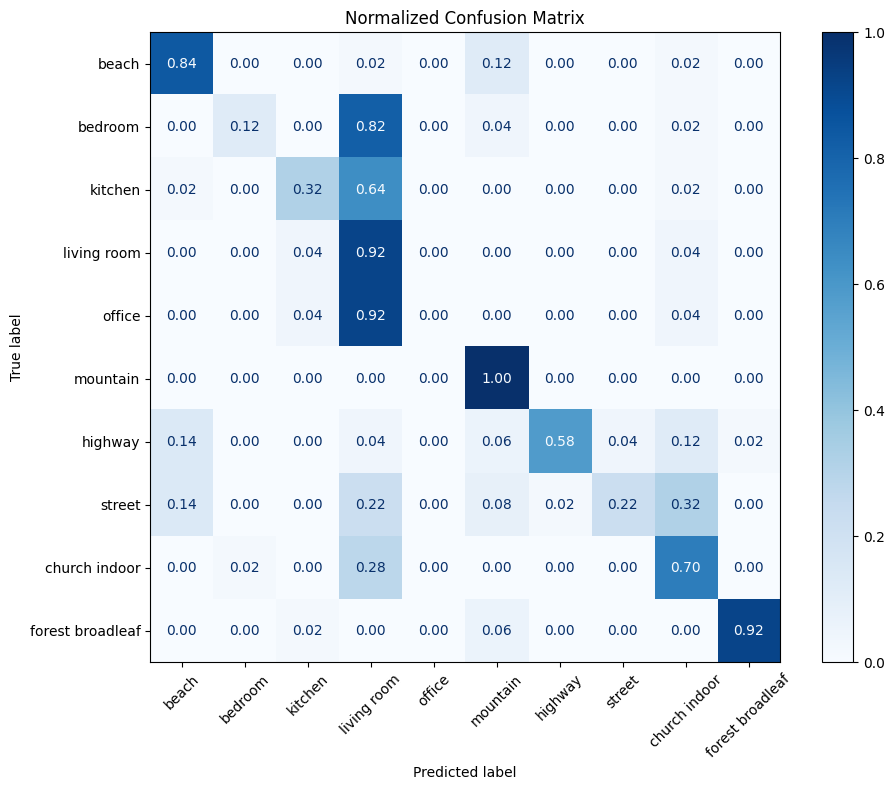

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


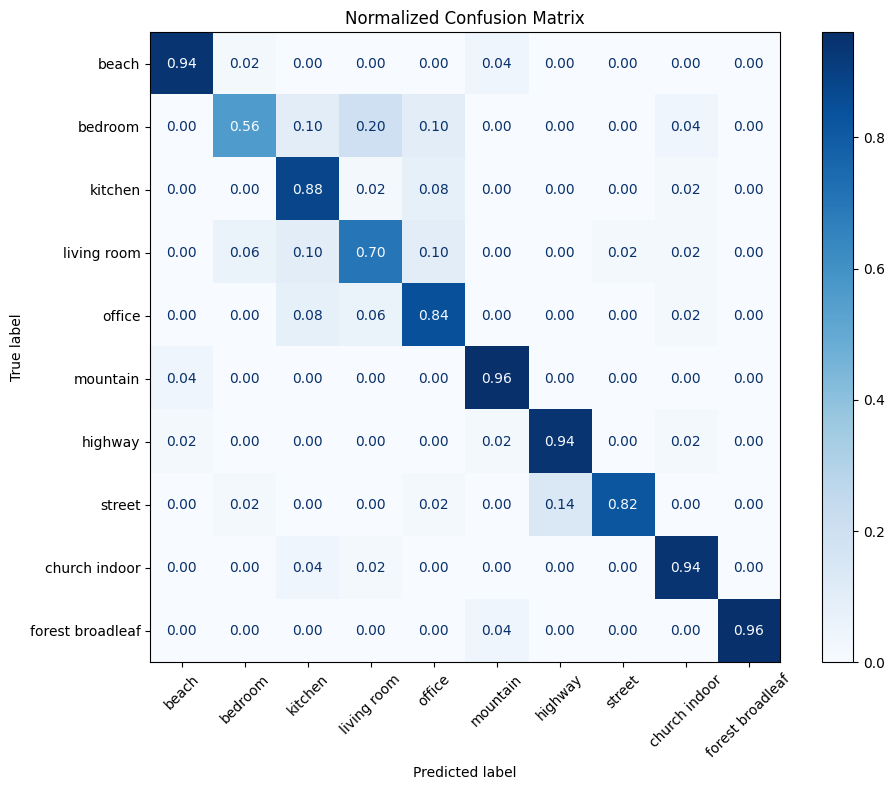

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


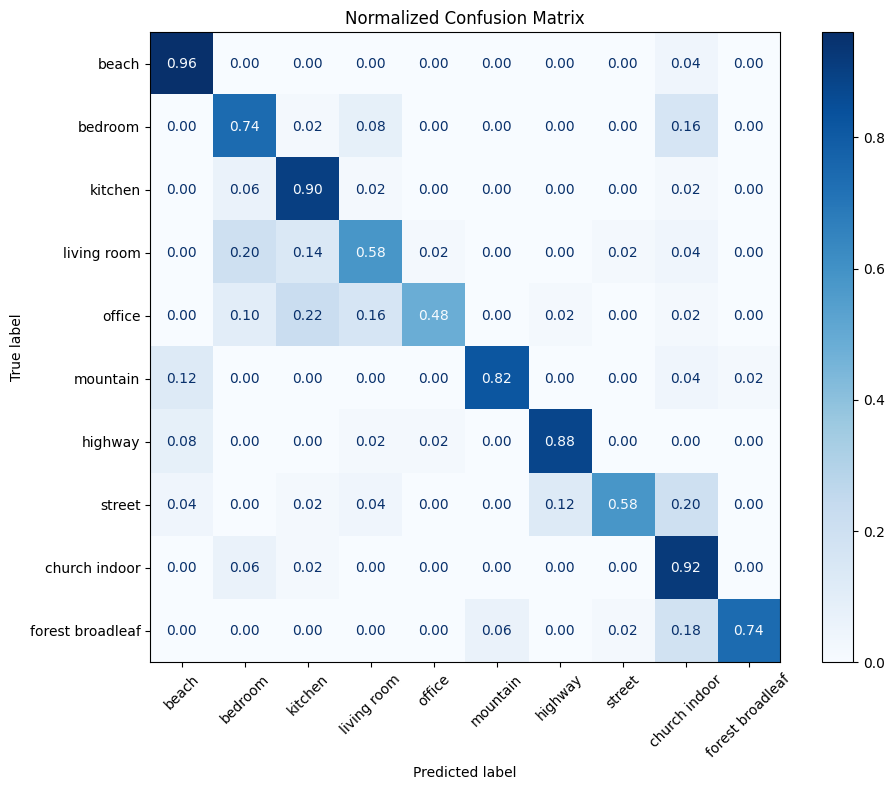

array([[0.96, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.04, 0.  ],
       [0.  , 0.74, 0.02, 0.08, 0.  , 0.  , 0.  , 0.  , 0.16, 0.  ],
       [0.  , 0.06, 0.9 , 0.02, 0.  , 0.  , 0.  , 0.  , 0.02, 0.  ],
       [0.  , 0.2 , 0.14, 0.58, 0.02, 0.  , 0.  , 0.02, 0.04, 0.  ],
       [0.  , 0.1 , 0.22, 0.16, 0.48, 0.  , 0.02, 0.  , 0.02, 0.  ],
       [0.12, 0.  , 0.  , 0.  , 0.  , 0.82, 0.  , 0.  , 0.04, 0.02],
       [0.08, 0.  , 0.  , 0.02, 0.02, 0.  , 0.88, 0.  , 0.  , 0.  ],
       [0.04, 0.  , 0.02, 0.04, 0.  , 0.  , 0.12, 0.58, 0.2 , 0.  ],
       [0.  , 0.06, 0.02, 0.  , 0.  , 0.  , 0.  , 0.  , 0.92, 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.06, 0.  , 0.02, 0.18, 0.74]])

In [66]:
#VISUALISE HEATMAP OF CONFUSION MATRIX BETWEEN CLASSES
plot_normalized_confusion_matrix(resnet18, val_loader, classes)
plot_normalized_confusion_matrix(efficientnet_b0, val_loader, classes)
plot_normalized_confusion_matrix(mobilenet_v3, val_loader, classes)

In [49]:
#SAVE WEIGHTS OF BEST PERFORMING MODEL
os.makedirs("checkpoints", exist_ok=True)

MODEL_PATH = "checkpoints/efficientnet_b0_sun_model_2.pth"
torch.save(efficientnet_b0.state_dict(), MODEL_PATH)
print("Saved to", MODEL_PATH)


Saved to checkpoints/efficientnet_b0_sun_model_2.pth


In [56]:
#LOG INTO HUGGING FACE
!pip install -q huggingface_hub

from huggingface_hub import notebook_login
notebook_login()  # will open a widget to paste your HF token

from huggingface_hub import login

login(token="INSERT_TOKEN")

In [57]:
#CREATE A FOLDER FOR THE HUB
import json
import shutil

model_dir = "efficientnet-sun10"
os.makedirs(model_dir, exist_ok=True)

# copy weights as pytorch_model.bin
shutil.copy(MODEL_PATH, os.path.join(model_dir, "pytorch_model.bin"))

# minimal config: adjust to your setup
config = {
    "model_type": "efficientnet_b0",
    "num_classes": 10,
    "id_to_label": {str(i): name for i, name in enumerate(classes)},
    "label_to_id": {name: i for i, name in enumerate(classes)},
}

with open(os.path.join(model_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

In [58]:
#PUSH FOLDER TO HUGGING FACE HUB
from huggingface_hub import create_repo, upload_folder

repo_id = "SharmarkeO/efficientnet-b0-sun10"  # change to your HF handle

# Create repo if it doesn't exist (public by default)
create_repo(repo_id, exist_ok=True)

# Upload everything in model_dir
upload_folder(
    repo_id=repo_id,
    folder_path=model_dir,
    commit_message="Add EfficientNet-B0 SUN10 weights",
)


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...t-sun10/pytorch_model.bin:   3%|3         |  554kB / 16.4MB            

CommitInfo(commit_url='https://huggingface.co/SharmarkeO/efficientnet-b0-sun10/commit/2e6759965df8061a83a8173b2cff0086ff438457', commit_message='Add EfficientNet-B0 SUN10 weights', commit_description='', oid='2e6759965df8061a83a8173b2cff0086ff438457', pr_url=None, repo_url=RepoUrl('https://huggingface.co/SharmarkeO/efficientnet-b0-sun10', endpoint='https://huggingface.co', repo_type='model', repo_id='SharmarkeO/efficientnet-b0-sun10'), pr_revision=None, pr_num=None)